In [8]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay


In [20]:
def load_digit_anomaly_dataset(
    normal_digit=0,
    anomaly_digits=None,
    n_train_normal=120,
    n_test_normal=40,
    n_test_anomaly=120,
    n_components=8,
    random_state=7,
):
    """
    Load sklearn 8x8 digit images and build an anomaly-detection dataset.

    Training set:
        only normal images.

    Test set:
        normal images + anomaly images.

    Returns:
        X_train_q: PCA-reduced and angle-scaled train features.
        X_test_q: PCA-reduced and angle-scaled test features.
        y_test: 0 for normal, 1 for anomaly.
        raw: dictionary with original images for visualization.
    """
    if anomaly_digits is None:
        anomaly_digits = [d for d in range(10) if d != normal_digit]

    digits = load_digits()  #load dataset load from sklearn
    X = digits.data.astype(float) / 16.0 #normalize pixel values to [0, 1]
    y = digits.target #labels for each image (0-9)
    images = digits.images.astype(float) / 16.0 #original 8x8 images for visualization

    normal_idx = np.where(y == normal_digit)[0] #indices of normal images
    anomaly_idx = np.where(np.isin(y, anomaly_digits))[0] #indices of anomaly images

    rng = np.random.default_rng(random_state) #random number generator for reproducibility
    normal_idx = rng.permutation(normal_idx) #shuffle normal indices
    anomaly_idx = rng.permutation(anomaly_idx) #shuffle anomaly indices

    train_normal_idx = normal_idx[:n_train_normal] #first n_train_normal normal indices for training
    test_normal_idx = normal_idx[n_train_normal:n_train_normal + n_test_normal] #next n_test_normal normal indices for testing
    test_anomaly_idx = anomaly_idx[:n_test_anomaly] #first n_test_anomaly anomaly indices for testing

    X_train = X[train_normal_idx] #training features (only normal)
    X_test = np.vstack([X[test_normal_idx], X[test_anomaly_idx]]) #test features (normal + anomaly)

    y_test = np.concatenate([
        np.zeros(len(test_normal_idx), dtype=int),
        np.ones(len(test_anomaly_idx), dtype=int),
    ]) #test labels: 0 for normal, 1 for anomaly

    test_indices = np.concatenate([test_normal_idx, test_anomaly_idx]) #indices of test samples in original dataset

    # Standardize before PCA.
    scaler = StandardScaler() #standardize features to have mean=0 and variance=1 for PCA
    X_train_scaled = scaler.fit_transform(X_train) #fit scaler on training data and transform
    X_test_scaled = scaler.transform(X_test) #transform test data using the same scaler

    pca = PCA(n_components=n_components, random_state=random_state) #PCA for dimensionality reduction to n_components
    X_train_pca = pca.fit_transform(X_train_scaled) #fit PCA on training data and transform
    X_test_pca = pca.transform(X_test_scaled) #transform test data using the same PCA

    # Scale PCA features to quantum rotation angles in [0, pi].
    angle_scaler = MinMaxScaler(feature_range=(0, np.pi)) #scale features to [0, pi] for quantum encoding
    X_train_q = angle_scaler.fit_transform(X_train_pca) #fit angle scaler on training PCA features and transform
    X_test_q = angle_scaler.transform(X_test_pca) #transform test PCA features using the same angle scaler

    # Store raw data for visualization.
    raw = {
        "train_images": images[train_normal_idx],
        "test_images": images[test_indices],
        "test_labels_original": y[test_indices],
        "explained_variance_ratio": pca.explained_variance_ratio_,
    }

    return X_train_q, X_test_q, y_test, raw

In [10]:
def evaluate_scores(y_true, anomaly_scores, threshold=None):
    """
    y_true:
        0 normal, 1 anomaly.

    anomaly_scores:
        larger should mean more anomalous.
    """
    auc = roc_auc_score(y_true, anomaly_scores)

    if threshold is None:
        # Simple default: choose the median score as a rough threshold.
        # For final result, Person 1 can improve this using validation.
        threshold = np.percentile(anomaly_scores, 75)

    y_pred = (anomaly_scores >= threshold).astype(int)

    return {
        "auc": auc,
        "f1": f1_score(y_true, y_pred),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "classification_report": classification_report(y_true, y_pred),
        "threshold": threshold,
        "y_pred": y_pred,
    }


def distance_baseline(X_train, X_test, y_test, k=5):
    """
    Anomaly score = average distance to k nearest normal training images.
    """
    D = pairwise_distances(X_test, X_train, metric="euclidean")
    nearest = np.sort(D, axis=1)[:, :k]
    scores = nearest.mean(axis=1)
    return evaluate_scores(y_test, scores)


def rbf_one_class_svm_baseline(X_train, X_test, y_test, nu=0.1, gamma="scale"):
    """
    Classical one-class SVM baseline using the usual RBF kernel.
    """
    model = OneClassSVM(kernel="rbf", nu=nu, gamma=gamma)
    model.fit(X_train)

    # sklearn decision_function: positive means inlier.
    # We flip sign so larger means more anomalous.
    scores = -model.decision_function(X_test)

    return evaluate_scores(y_test, scores)

In [11]:
def quantum_feature_map(x, reps=2):
    """
    Build a parameterized-looking feature map with actual numerical data x.

    Args:
        x: array of shape (n_qubits,)
        reps: number of repeated encoding/entangling layers.

    Returns:
        QuantumCircuit
    """
    x = np.asarray(x, dtype=float)
    n_qubits = len(x)

    qc = QuantumCircuit(n_qubits)

    for q in range(n_qubits):
        qc.h(q)

    for _ in range(reps):
        # Local data encoding.
        for q in range(n_qubits):
            qc.ry(float(x[q]), q)
            qc.rz(float(x[q]), q)

        # Nearest-neighbor nonlinear entangling features.
        for q in range(n_qubits - 1):
            angle = float((x[q] * x[q + 1]) / np.pi)
            qc.cx(q, q + 1)
            qc.rz(angle, q + 1)
            qc.cx(q, q + 1)

        # Optional ring entanglement if more than 2 qubits.
        if n_qubits > 2:
            angle = float((x[-1] * x[0]) / np.pi)
            qc.cx(n_qubits - 1, 0)
            qc.rz(angle, 0)
            qc.cx(n_qubits - 1, 0)

    return qc


def state_from_features(x, reps=2):
    """
    Encode one feature vector into a quantum statevector.
    """
    qc = quantum_feature_map(x, reps=reps)
    return Statevector.from_instruction(qc).data


def quantum_kernel_matrix(XA, XB=None, reps=2):
    """
    Compute quantum fidelity kernel matrix.

    K[i, j] = |<phi(XA[i]) | phi(XB[j])>|^2

    If XB is None, compute square train kernel.
    """
    XA = np.asarray(XA, dtype=float)

    if XB is None:
        XB = XA
    else:
        XB = np.asarray(XB, dtype=float)

    states_A = np.array([state_from_features(x, reps=reps) for x in XA])
    states_B = np.array([state_from_features(x, reps=reps) for x in XB])

    K = np.abs(states_A @ states_B.conj().T) ** 2

    # Numerical cleanup.
    K = np.real(K)
    K = np.clip(K, 0.0, 1.0)

    return K


def print_example_circuit(n_qubits=4, reps=2):
    """
    Useful for the notebook/presentation.
    """
    x = np.linspace(0.1, 1.0, n_qubits)
    qc = quantum_feature_map(x, reps=reps)
    print(qc.draw(output="text"))
    return qc

In [12]:
def quantum_kernel_one_class_svm(
    X_train,
    X_test,
    y_test,
    reps=2,
    nu=0.1,
):
    """
    Train a one-class SVM using a precomputed quantum kernel.

    Args:
        X_train: normal training examples, shape (n_train, n_features)
        X_test: test examples, shape (n_test, n_features)
        y_test: 0 normal, 1 anomaly
        reps: feature-map repetitions
        nu: expected outlier fraction / softness parameter

    Returns:
        results dictionary
    """
    K_train = quantum_kernel_matrix(X_train, reps=reps)
    K_test = quantum_kernel_matrix(X_test, X_train, reps=reps)

    model = OneClassSVM(kernel="precomputed", nu=nu)
    model.fit(K_train)

    # Positive = inlier, negative = outlier.
    # Flip sign so larger = more anomalous.
    scores = -model.decision_function(K_test)

    results = evaluate_scores(y_test, scores)

    results["K_train"] = K_train
    results["K_test"] = K_test
    results["scores"] = scores
    results["model"] = model

    return results

In [29]:
def run_all(
    normal_digit=0,
    anomaly_digits=None,
    n_components=6,
    reps=2,
    nu=0.1,
):
    X_train, X_test, y_test, raw = load_digit_anomaly_dataset(
        normal_digit=normal_digit,
        anomaly_digits=anomaly_digits,
        n_components=n_components,
    )
    print(raw["explained_variance_ratio"])
    print("Total kept:", raw["explained_variance_ratio"].sum())

    results = {}

    results["distance"] = distance_baseline(X_train, X_test, y_test)
    results["rbf_ocsvm"] = rbf_one_class_svm_baseline(X_train, X_test, y_test, nu=nu)
    results["quantum_kernel_ocsvm"] = quantum_kernel_one_class_svm(
        X_train,
        X_test,
        y_test,
        reps=reps,
        nu=nu,
    )

    return results, raw



results, raw = run_all(
    normal_digit=0,
    anomaly_digits=[1, 2, 3, 4, 5, 6, 7, 8, 9],
    n_components=10,
    reps=2,
    nu=0.1,
)

[0.16926094 0.14055507 0.10868895 0.07272187 0.05765702 0.04609621
 0.03798212 0.0331457  0.03100212 0.02881289]
Total kept: 0.7259228897321044


In [ ]:
print(results)

In [15]:
def plot_digit_grid(images, labels=None, n=16, title=None):
    n = min(n, len(images))
    cols = 8
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(1.4 * cols, 1.4 * rows))

    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.axis("off")
        if labels is not None:
            plt.title(str(labels[i]), fontsize=9)

    if title is not None:
        plt.suptitle(title)

    plt.tight_layout()
    plt.show()


def plot_kernel_heatmap(K, title="Quantum kernel matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(K, aspect="auto")
    plt.colorbar(label="kernel value")
    plt.title(title)
    plt.xlabel("image index")
    plt.ylabel("image index")
    plt.tight_layout()
    plt.show()


def plot_roc(y_test, scores, title="ROC curve"):
    RocCurveDisplay.from_predictions(y_test, scores)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_confusion(y_test, y_pred, title="Confusion matrix"):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["normal", "anomaly"],
    )
    plt.title(title)
    plt.tight_layout()
    plt.show()


def show_most_anomalous(raw, scores, top_k=10):
    idx = np.argsort(scores)[-top_k:][::-1]
    images = raw["test_images"][idx]
    labels = raw["test_labels_original"][idx]
    plot_digit_grid(images, labels=labels, n=top_k, title="Most anomalous images")


def show_most_normal(raw, scores, top_k=10):
    idx = np.argsort(scores)[:top_k]
    images = raw["test_images"][idx]
    labels = raw["test_labels_original"][idx]
    plot_digit_grid(images, labels=labels, n=top_k, title="Most normal-looking images")

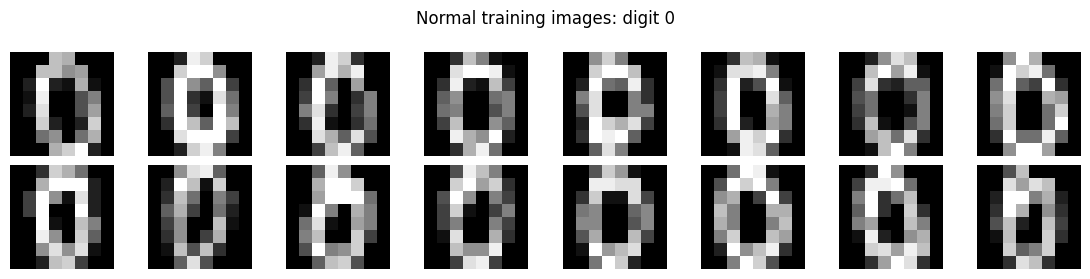

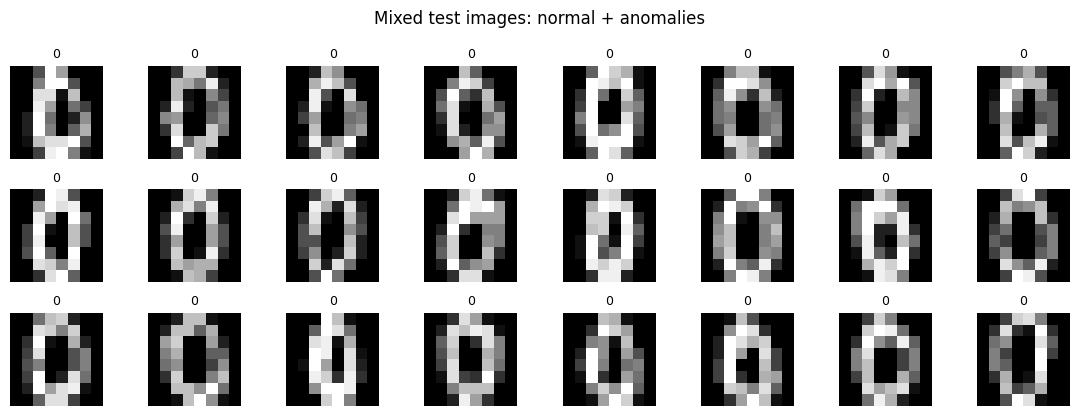

In [16]:
X_train, X_test, y_test, raw = load_digit_anomaly_dataset(
    normal_digit=0,
    anomaly_digits=[1,2,3,4,5,6,7,8,9],
    n_components=4,
    n_train_normal=120,
    n_test_normal=40,
    n_test_anomaly=120,
    random_state=7,
)

plot_digit_grid(raw["train_images"], n=16, title="Normal training images: digit 0")
plot_digit_grid(
    raw["test_images"],
    labels=raw["test_labels_original"],
    n=24,
    title="Mixed test images: normal + anomalies",
)

In [17]:
qc = print_example_circuit(n_qubits=4, reps=2)

distance_results = distance_baseline(X_train, X_test, y_test)
rbf_results = rbf_one_class_svm_baseline(X_train, X_test, y_test, nu=0.1)

print("Distance baseline")
print(distance_results["classification_report"])

print("RBF one-class SVM")
print(rbf_results["classification_report"])

     ┌───┐┌─────────┐┌─────────┐                                               »
q_0: ┤ H ├┤ Ry(0.1) ├┤ Rz(0.1) ├──■────────────────────■───────────────────────»
     ├───┤├─────────┤├─────────┤┌─┴─┐┌──────────────┐┌─┴─┐                     »
q_1: ┤ H ├┤ Ry(0.4) ├┤ Rz(0.4) ├┤ X ├┤ Rz(0.012732) ├┤ X ├──■──────────────────»
     ├───┤├─────────┤├─────────┤└───┘└──────────────┘└───┘┌─┴─┐┌──────────────┐»
q_2: ┤ H ├┤ Ry(0.7) ├┤ Rz(0.7) ├──────────────────────────┤ X ├┤ Rz(0.089127) ├»
     ├───┤└┬───────┬┘└┬───────┬┘                          └───┘└──────────────┘»
q_3: ┤ H ├─┤ Ry(1) ├──┤ Rz(1) ├────────────────────────────────────────────────»
     └───┘ └───────┘  └───────┘                                                »
«                                       ┌───┐┌───────────┐           ┌───┐»
«q_0: ──────────────────────────────────┤ X ├┤ Rz(1/10π) ├───────────┤ X ├»
«          ┌─────────┐ ┌─────────┐      └─┬─┘└───────────┘           └─┬─┘»
«q_1: ──■──┤ Ry(0.4) ├─┤ Rz(0.4) ├────────┼

In [18]:
quantum_results = quantum_kernel_one_class_svm(
    X_train,
    X_test,
    y_test,
    reps=2,
    nu=0.1,
)

print("Quantum kernel one-class SVM")
print(quantum_results["classification_report"])

Quantum kernel one-class SVM
              precision    recall  f1-score   support

           0       0.33      1.00      0.50        40
           1       1.00      0.33      0.50       120

    accuracy                           0.50       160
   macro avg       0.67      0.67      0.50       160
weighted avg       0.83      0.50      0.50       160



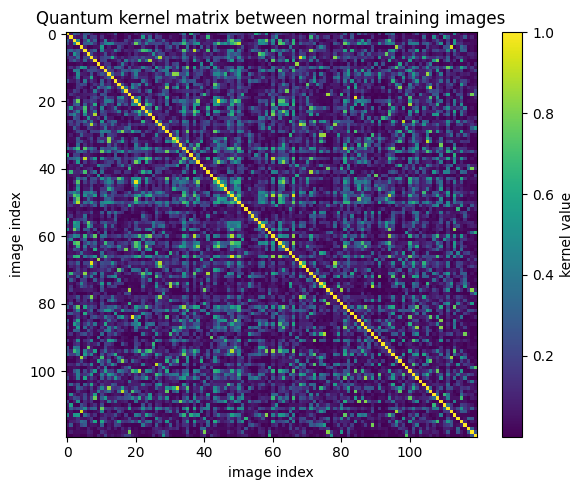

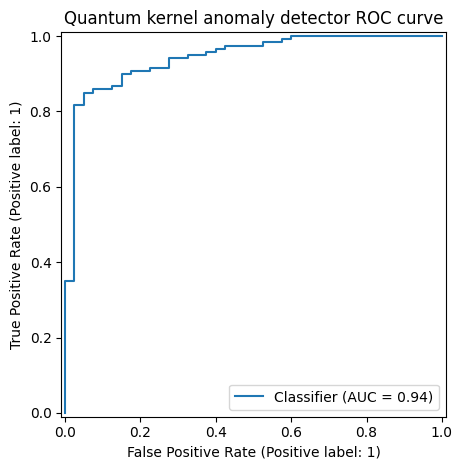

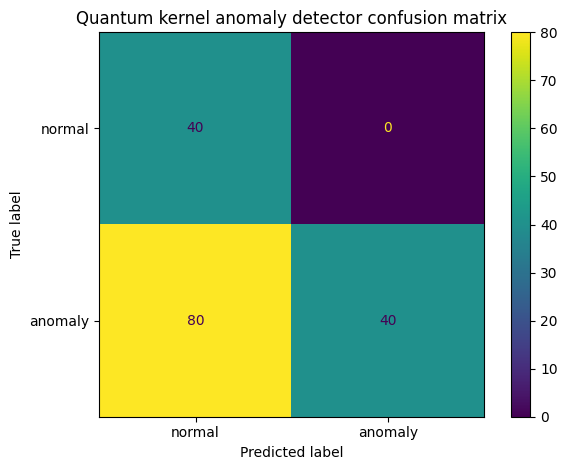

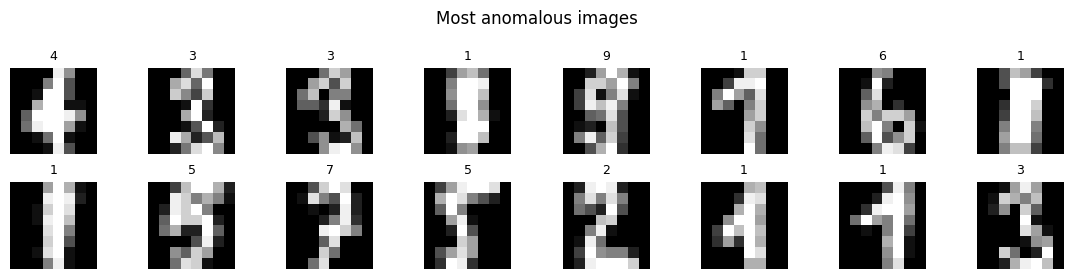

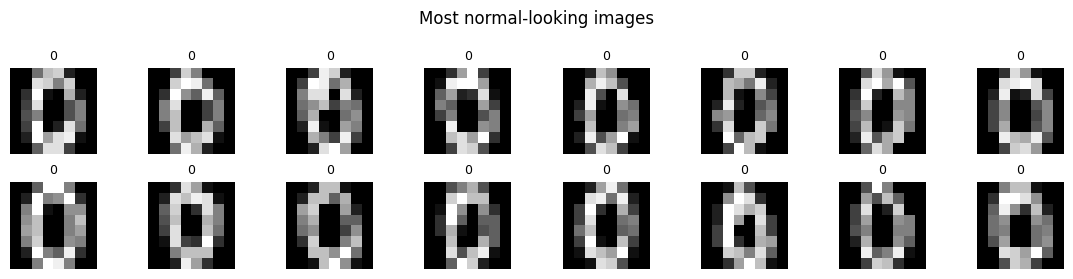

In [19]:
plot_kernel_heatmap(
    quantum_results["K_train"],
    title="Quantum kernel matrix between normal training images",
)

plot_roc(
    y_test,
    quantum_results["scores"],
    title="Quantum kernel anomaly detector ROC curve",
)

plot_confusion(
    y_test,
    quantum_results["y_pred"],
    title="Quantum kernel anomaly detector confusion matrix",
)

show_most_anomalous(raw, quantum_results["scores"], top_k=16)
show_most_normal(raw, quantum_results["scores"], top_k=16)